In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/compas_clean.csv")
df.shape

(6172, 7)

In [2]:
df["race"].value_counts()


race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Asian                 31
Native American       11
Name: count, dtype: int64

In [3]:
main = df[df["race"].isin(["African-American", "Caucasian"])].copy()
main["race"].value_counts()

race
African-American    3175
Caucasian           2103
Name: count, dtype: int64

In [4]:
main.groupby("race")["two_year_recid"].mean()

race
African-American    0.52315
Caucasian           0.39087
Name: two_year_recid, dtype: float64

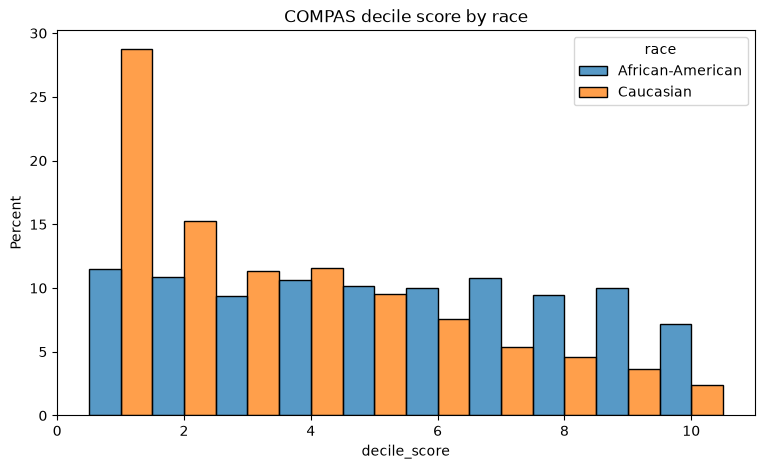

In [5]:
plt.figure(figsize=(9, 5))
sns.histplot(data=main, x="decile_score", hue="race", multiple="dodge",
             discrete=True, stat="percent", common_norm=False)
plt.title("COMPAS decile score by race")
plt.savefig("../reports/decile_score_by_race.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
main.groupby("race")["priors_count"].describe()

,count,mean,std,min,25%,50%,75%,max
race,,,,,,,,
African-American,3175.0,4.238110,5.436405,0.0,0.0,2.0,6.0,38.0
Caucasian,2103.0,2.289111,3.573759,0.0,0.0,1.0,3.0,36.0


In [7]:
  main["high_risk"] = (main["decile_score"] >= 5).astype(int)
  main.groupby("race")["high_risk"].mean()

race
African-American    0.576063
Caucasian           0.330956
Name: high_risk, dtype: float64

In [8]:
  main.groupby("race")["priors_count"].describe()


,count,mean,std,min,25%,50%,75%,max
race,,,,,,,,
African-American,3175.0,4.238110,5.436405,0.0,0.0,2.0,6.0,38.0
Caucasian,2103.0,2.289111,3.573759,0.0,0.0,1.0,3.0,36.0


In [9]:
main.groupby(["decile_score", "race"])["two_year_recid"].mean().unstack()

race,African-American,Caucasian
decile_score,,
1,0.232877,0.211570
2,0.303468,0.311526
3,0.419463,0.344538
4,0.468843,0.403292
5,0.489164,0.455000
6,0.588050,0.581250
7,0.609329,0.601770
8,0.714286,0.750000
9,0.722397,0.714286


In [10]:
  main.groupby(["decile_score", "race"]).size().unstack()

race,African-American,Caucasian
decile_score,,
1,365,605
2,346,321
3,298,238
4,337,243
5,323,200
6,318,160
7,343,113
8,301,96
9,317,77


## Exploratory Findings & Calibration Analysis

### 1. Base Rates & Score Distribution
* **Base rearrest rates (`two_year_recid`):**
  * African-American defendants: **52.32%** were rearrested within two years.
  * Caucasian defendants: **39.09%** were rearrested within two years.
* **Score distribution:**
  * Scores for Caucasian defendants are heavily right-skewed: **28.8%** receive a decile score of 1 and only **2.38%** receive a 10.
  * Scores for African-American defendants are spread much more evenly across the scale, ranging between **7.15%** and **11.5%** per score.
* **Share flagged medium or high risk (decile score of 5 or above):**
  * African-American: **58%**
  * Caucasian: **33%**

---

### 2. Prior Offense History (`priors_count`)
* **African-American:** mean of **4.24** prior offenses (median 2.0).
* **Caucasian:** mean of **2.29** prior offenses (median 1.0).
* *Note:* Prior offense history differs substantially between the groups, which likely contributes to the score gap. COMPAS is proprietary, so its exact inputs and weights are not public.

---

### 3. Calibration Table

Rearrest rate at each COMPAS decile score, by group:

| `decile_score` | African-American | Caucasian |
| :---: | :---: | :---: |
| **1** | 23.29% | 21.16% |
| **2** | 30.35% | 31.15% |
| **3** | 41.95% | 34.45% |
| **4** | 46.88% | 40.33% |
| **5** | 48.92% | 45.50% |
| **6** | 58.81% | 58.13% |
| **7** | 60.93% | 60.18% |
| **8** | 71.43% | 75.00% |
| **9** | 72.24% | 71.43% |
| **10** | 83.70% | 70.00% |

At most scores, the actual rearrest rate is similar for both groups, so a given score means roughly the same thing regardless of race. This property is called **calibration**.

> **Small-sample caveat:** At decile 10, there are 227 African-American defendants but only 50 Caucasian defendants. The rearrest rates differ (83.7% vs. 70.0%), but the Caucasian estimate rests on a small sample and is less certain, so this gap should be read with caution.

---

### 4. What this means for modelling
The groups have different base rates (52.3% vs. 39.1%) and different prior offense histories, while the scores are roughly calibrated. A model trained without race as a feature may still produce different error rates across groups, because these other variables differ. The next steps test this directly.

In [11]:
main["high_risk"] = (main["decile_score"] >= 5).astype(int)
main.groupby("race")["high_risk"].mean()

race
African-American    0.576063
Caucasian           0.330956
Name: high_risk, dtype: float64